Lab 8 Linear Dataset

Jorge Angon, Swati K, George Rodriguez

kaggle: https://www.kaggle.com/datasets/samuelcortinhas/credit-card-approval-clean-data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# load the dataset
df = pd.read_csv("clean_dataset.csv")

# look at the first few rows
print(df.head())

# show the size of the dataset
print("Dataset shape:", df.shape)


   Gender    Age   Debt  Married  BankCustomer     Industry Ethnicity  \
0       1  30.83  0.000        1             1  Industrials     White   
1       0  58.67  4.460        1             1    Materials     Black   
2       0  24.50  0.500        1             1    Materials     Black   
3       1  27.83  1.540        1             1  Industrials     White   
4       1  20.17  5.625        1             1  Industrials     White   

   YearsEmployed  PriorDefault  Employed  CreditScore  DriversLicense  \
0           1.25             1         1            1               0   
1           3.04             1         1            6               0   
2           1.50             1         0            0               0   
3           3.75             1         1            5               1   
4           1.71             1         0            0               0   

        Citizen  ZipCode  Income  Approved  
0       ByBirth      202       0         1  
1       ByBirth       43     560

In [12]:
# separate input features and target labels
X = df.drop("Approved", axis=1)
y = df["Approved"]

# turn text columns into numbers
X = pd.get_dummies(X, drop_first=True)

In [13]:
# split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# create an SVM classifier with a linear kernel
svm_classifier = SVC(kernel='linear', C=1.0)

# train the SVM model using the training data
svm_classifier.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [15]:
# make predictions on the test data
y_pred = svm_classifier.predict(X_test_scaled)

# calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# show more model results
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# print support vectors
print(f"\nNumber of support vectors: {len(svm_classifier.support_vectors_)}")

Accuracy: 87.68%

Classification Report:
              precision    recall  f1-score   support

Not Approved       0.92      0.86      0.89        77
    Approved       0.83      0.90      0.87        61

    accuracy                           0.88       138
   macro avg       0.88      0.88      0.88       138
weighted avg       0.88      0.88      0.88       138

Confusion Matrix:
[[66 11]
 [ 6 55]]

Number of support vectors: 184


In [16]:
# make one new applicant row
new_customer = pd.DataFrame([{
    "Gender": 1,
    "Age": 30.83,
    "Debt": 0.00,
    "Married": 1,
    "BankCustomer": 1,
    "Industry": "Industrials",
    "Ethnicity": "White",
    "YearsEmployed": 1.25,
    "PriorDefault": 1,
    "Employed": 1,
    "CreditScore": 1,
    "DriversLicense": 0,
    "Citizen": "ByBirth",
    "ZipCode": 202,
    "Income": 0
}])

# combine the new customer with the original input data
all_inputs = df.drop("Approved", axis=1)
combined_data = pd.concat([all_inputs, new_customer], ignore_index=True)

# turn text columns into numbers
combined_encoded = pd.get_dummies(combined_data, drop_first=True)

# grab only the last row because that is the new customer
new_customer_encoded = combined_encoded.tail(1)

# force the new row to have the same columns as the training data
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

# scale the new row
new_customer_scaled = scaler.transform(new_customer_encoded)

# predict the result
new_prediction = svm_classifier.predict(new_customer_scaled)[0]

if new_prediction == 1:
    print("Prediction for new customer: Approved")
else:
    print("Prediction for new customer: Not Approved")

Prediction for new customer: Approved


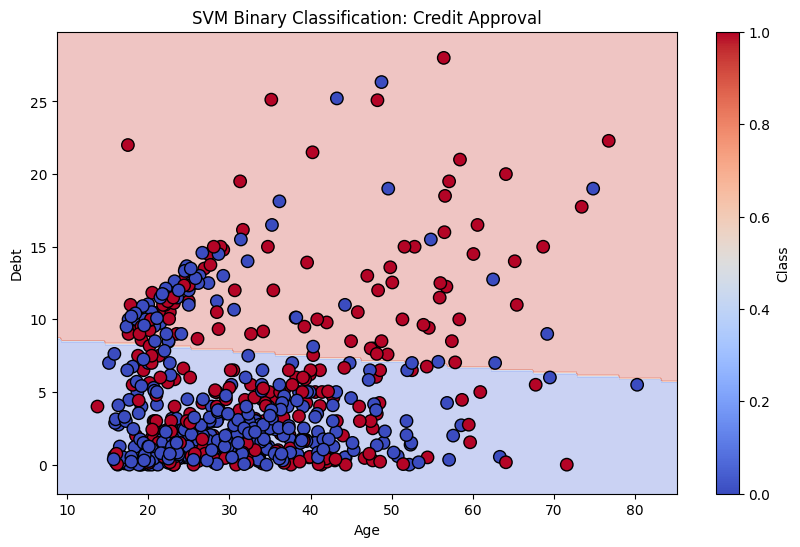

In [17]:
# use only 2 features for the graph
X_vis = df[["Age", "Debt"]]
y_vis = df["Approved"]

# split the graph data
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42, stratify=y_vis
)

# scale the graph data
scaler_vis = StandardScaler()
X_train_vis_scaled = scaler_vis.fit_transform(X_train_vis)
X_test_vis_scaled = scaler_vis.transform(X_test_vis)

# train a second linear SVM just for the graph
svm_vis = SVC(kernel='linear', C=1.0)
svm_vis.fit(X_train_vis_scaled, y_train_vis)

# create the background points for the graph
x_min, x_max = X_vis["Age"].min() - 5, X_vis["Age"].max() + 5
y_min, y_max = X_vis["Debt"].min() - 2, X_vis["Debt"].max() + 2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                     np.arange(y_min, y_max, 0.2))

# predict each point in the graph
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["Age", "Debt"])
grid_points_scaled = scaler_vis.transform(grid_points)
Z = svm_vis.predict(grid_points_scaled)
Z = Z.reshape(xx.shape)

# plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_vis["Age"], X_vis["Debt"], c=y_vis, edgecolors='k', cmap='coolwarm', s=80)
plt.xlabel('Age')
plt.ylabel('Debt')
plt.title('SVM Binary Classification: Credit Approval')
plt.colorbar(label='Class')
plt.show()

This project used a linear SVM model to predict whether a credit card application would be approved or not approved. The model was trained on past application data and then tested on new records. After preparing the data and running the model, it reached 87.68% accuracy.

In the test results, the model correctly identified 66 out of 77 not approved applications and 55 out of 61 approved applications. This shows the model was balanced and did not only perform well for one type of result. The confusion matrix and classification report helped show that the model was reliable overall.

This means the model did a good job spotting which applications looked likely to be approved and which looked more risky. It is not perfect but it gives a strong starting point for decision support. Overall, the results show that a linear SVM can be a useful tool for helping review credit application decisions in a faster and more consistent way.